# 1. Motivation

The story we wanted to tell was about the mortality crisis in Russia, how it relates to alcohol consumption and how new laws and other government actions have been able to combat this. We combined multiple dataset since we found using only one would not be possible to get all the information and context needed for the story.

Our datasets are:

* Results from a 2021 study on the Global Burden of Disease (GBD) https://vizhub.healthdata.org/gbd-results?params=gbd-api-2021-permalink/e536e88427a28a4e136289ad19ec6c0b. This dataset provides annual cause-specific mortality data globally, including metrics such as number of deaths, death rates, and Years of Life Lost (YLLs). We filtered this data by country (Russia and others), sex, and causes of death  This dataset was chosen because it contains mortality data over the whole period we wanted to look at (the past 30 years) for all the countries the world. The data can be filtered by causes of death specifically related to alcohol (including alcoholic liver disease, alcohol use disorders, alcoholic cardiomyopathy, and alcohol-attributable cancers) along with sex, age and country. This data was used to compare the alcohol-related mortality in Russia to the rest of the world. It was also used to compare Years of Life Lost due to alcohol-related mortality in Russia between the sexes.

What is your dataset?
Why did you choose this/these particular dataset(s)?
What was your goal for the end user's experience?

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Basic stats. Let's understand the dataset better

- The GBD data contains global health statistics and offers a lot of dimension: Cause (e.g., alcohol use disorders, total cancers), Measure (e.g., YLLs, deaths), Metric (e.g., rate, number), Location (e.g., national level: Russia), Age (e.g., specific years or grouped categories), Sex (male, female), Year (annual data available from 1980 to 2021). 

The data was queried online https://vizhub.healthdata.org/gbd-results/, producing a few different csv files that were then further processed. We started by querying the data by Cause: all, Metric: number, Location: Russia, Age: all, Year: 1990-2021. This was used to plot the causes of death in Russia over the years. The top 8 causes of death were selected (because a larger number made the plot hard to read), then the four alcohol-related causes (alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use) were grouped as one cause and plotted along with the others for comparison.

<Figure size 1400x600 with 0 Axes>

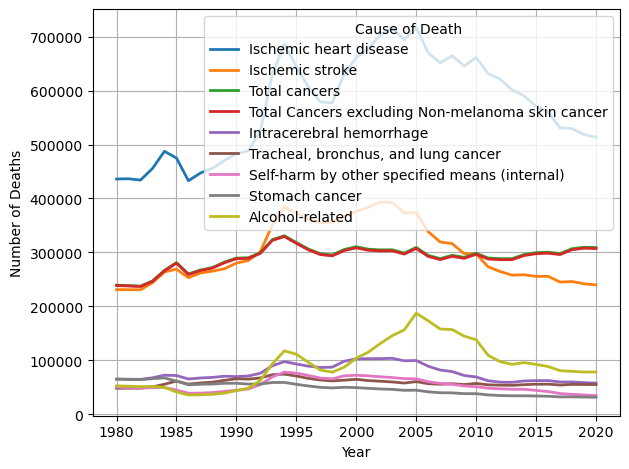

In [38]:
df = pd.read_csv("assets/data/cod_russia.csv" )

filtered_df = df[
    (df['measure'] == 'Deaths') &
    (df['sex'] == 'Both') &
    (df['age'] == 'All ages')
]

pivot_df = filtered_df.pivot_table(index='year', columns='cause', values='val', aggfunc='sum')

alcohol_causes = [
    'Alcohol use disorders',
    'Alcoholic cardiomyopathy',
    'Cirrhosis due to alcohol',
    'Liver cancer due to alcohol use'
]

pivot_df['Alcohol-related'] = pivot_df[alcohol_causes].sum(axis=1)

pivot_df_reduced = pivot_df.drop(columns=[col for col in alcohol_causes if col in pivot_df.columns])

top_non_alcohol_causes_8 = (
    pivot_df_reduced.drop(columns='Alcohol-related')
    .sum()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plot_df = pivot_df_reduced[list(top_non_alcohol_causes_8) + ['Alcohol-related']]

plt.figure(figsize=(14, 6))
plot_df.plot(kind='line', linewidth=2)
plt.xlabel('Year')
plt.ylabel('Number of Deaths')
plt.legend(title='Cause of Death', loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()


After looking at all the different causes, we queryed the data by Cause: alcohol-related causes (alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use), Measure: death, YLLs, Metric: rate, Location: all countries, Age: all, Sex: all, Year: 1990, 2000, 2010, 2020. We grouped the alcohol-related causes together as one, and found the total mortality rate for each country. The top 10 countries with the highest mortality in the selected years were looked at. 

In [39]:
df = pd.read_csv("assets/data/global-alcohol-deaths.csv")

deaths_df = df[df['measure'] == 'Deaths']
ylls_df = df[df['measure'].str.contains('YLL')]

top_deaths_unique = deaths_df.sort_values(by='val', ascending=False).drop_duplicates(subset='location').head(10)
top_ylls_unique = ylls_df.sort_values(by='val', ascending=False).drop_duplicates(subset='location').head(10)

top_death_countries = top_deaths_unique['location'].tolist()
top_yll_countries = top_ylls_unique['location'].tolist()

print("Top 10 countries by deaths of alcohol-related diseases:")
count=1
for country in top_death_countries:
    print("{}. {}".format(count, country) )
    count+=1

print("\nTop 10 countries by YLLs (Years of Life Lost) by alcohol-related diseases:")
count=1
for country in top_yll_countries:
    print("{}. {}".format(count, country) )
    count+=1

Top 10 countries by deaths of alcohol-related diseases:
1. Russian Federation
2. Republic of Moldova
3. Belarus
4. Hungary
5. Latvia
6. Romania
7. Ukraine
8. Estonia
9. Greenland
10. Mongolia

Top 10 countries by YLLs (Years of Life Lost) by alcohol-related diseases:
1. Russian Federation
2. Republic of Moldova
3. Belarus
4. Hungary
5. Ukraine
6. Latvia
7. Estonia
8. Mongolia
9. Greenland
10. Romania


Finally, it was decided to query the data by Cause: alcohol-related causes (alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use), Measure: death, Metric: rate, Location: Russia, Denmark, China, United States, France, Belarus, Age: all, Sex: all, Year: 1990-2020. This file is 97KB and was used to create a visualization putting Russian alcohol-related mortality rates in global context. It was also queryed by Cause: alcohol-related causes (alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use), Metric: YLLs, Location: Russia, Age: all, Sex: Male/Female, Year: 1990-2020. This file is 40KB and was used to create a visualization showing the Years of Life Lost between men and women in Russia.

# 3. Data Analysis

We used the Global Burden of Disease (GBD) 2021 dataset to understand alcohol-related mortality trends in Russia and compare them to the rest of the world. The GBD data was filtered to focus on causes that are explicitly linked to alcohol which were: alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use. Then we looked at the values for YLLs (Years of Life Lost) and death for all countries during the period we wanted to investigate (1990-2021). Russia had the highest alcohol related mortality and YYLs each year with the few countries coming close to it also being from Eastern Europe. 

# 4. Genre. Which genre of data story did you use?
Which tools did you use from each of the 3 categories of Visual Narrative (Figure 7 in Segal and Heer). Why?
Which tools did you use from each of the 3 categories of Narrative Structure (Figure 7 in Segal and Heer). Why?


# 5. Visualizations.

A simple lineplot was decided to be the best way to showcase the higher alcohol-related mortality in Russia compared to the rest of the world. Since Russia had the highest mortality of all, with some Eastern Euroean counries coming close, we decided to include one country from the same region, Belarus, and four others were randomly selected: China, Denmark, France, The United States of America. We wanted this plot to convey that alcohol related deaths in Russia stand out in two ways, they are a lot more common than elsewhere and the mortality rate has gone through a lot of swings in the past 30 years.

To highlight the gender disparity in alcohol-related mortality, a stacked area chart displaying Years of Life Lost (YLLs) in Russia from 1990 to 2021, stratified by sex, was used. It covers four alcohol-related causes of death: alcohol use disorders, alcoholic cardiomyopathy, cirrhosis due to alcohol, and liver cancer due to alcohol use. The y-axis shows the total YLLs in millions. The two colored areas separate the male and female contributions to alcohol-related premature mortality over time. This well supports our story's narrative which includes making the gender disparity in alcohol-related mortality visible. The much larger area for men visually reinforces that Russian men bear a disproportionate burden of premature death due to alcohol. 


# 6. Discussion. Think critically about your creation
What went well?,
What is still missing? What could be improved?, Why?


# 7. Contributions. Who did what?
You should write (just briefly) which group member was the main responsible for which elements of the assignment. (I want you guys to understand every part of the assignment, but usually there is someone who took lead role on certain portions of the work. That's what you should explain).